# 4. Supervised Models - CNN3D - Salinas

Conv3D ile uzamsal (H×W) ve spektral (bant) eksenler birlikte işlenir.
Giriş formatı: (N, 1, D, H, W) — D=30 spektral bant, H=W=15 uzamsal boyut.

### Adım 1: Google Colab ve Google Drive Hazırlığı

In [1]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
    print("\n✅ Google Colab ortamı algılandı. Drive başarıyla bağlandı.")
except ModuleNotFoundError:
    IN_COLAB = False
    print("\n💻 Lokal ortam algılandı. (VS Code vb.)")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

✅ Google Colab ortamı algılandı. Drive başarıyla bağlandı.


### Adım 2: Gerekli Kütüphanelerin Yüklenmesi

In [2]:
if IN_COLAB:
    !pip install -q torch torchvision scikit-learn seaborn matplotlib

import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, cohen_kappa_score, confusion_matrix, classification_report
from sklearn.model_selection import StratifiedKFold
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from IPython.display import display

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\n🚀 Kullanılan cihaz: {device}")


🚀 Kullanılan cihaz: cuda


### Adım 3: Verilerin Yüklenmesi

In [3]:
if IN_COLAB:
    PROCESSED_DIR = '/content/drive/MyDrive/datasets/processed'
    if not os.path.exists(PROCESSED_DIR):
        print(f"⚠️ UYARI: {PROCESSED_DIR} bulunamadı!")
else:
    PROCESSED_DIR = './datasets/processed'

dataset_prefix = 'salinas_gauss0.5_pca30'

X_train = np.load(os.path.join(PROCESSED_DIR, f'{dataset_prefix}_X_train.npy'))
y_train = np.load(os.path.join(PROCESSED_DIR, f'{dataset_prefix}_y_train.npy'))
X_test  = np.load(os.path.join(PROCESSED_DIR, f'{dataset_prefix}_X_test.npy'))
y_test  = np.load(os.path.join(PROCESSED_DIR, f'{dataset_prefix}_y_test.npy'))

print(f"X_train: {X_train.shape}")
print(f"X_test : {X_test.shape}")

X_train: (43303, 15, 15, 30)
X_test : (10826, 15, 15, 30)


### Adım 4: CNN3D Model Tanımı ve Hiperparametreler

Conv2D'den farkı: giriş (N, 1, D, H, W) formatında.
- 1: tek kanal (gri küp gibi)
- D=30: spektral derinlik
- H=W=15: uzamsal boyut

Conv3D filtresi aynı anda hem spektral hem uzamsal komşulukları tarar.

In [4]:
class HSI_CNN3D(nn.Module):
    def __init__(self, num_classes, spectral_depth=30):
        super(HSI_CNN3D, self).__init__()
        self.conv_block = nn.Sequential(
            nn.Conv3d(1, 32, kernel_size=(3, 3, 3), padding=0),
            nn.BatchNorm3d(32),
            nn.ReLU(),

            nn.Conv3d(32, 64, kernel_size=(3, 3, 3), padding=0),
            nn.BatchNorm3d(64),
            nn.ReLU(),
            nn.MaxPool3d(kernel_size=(2, 2, 2))
        )
        self.fc_block = nn.Sequential(
            nn.Linear(64 * 13 * 5 * 5, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.conv_block(x)
        x = x.view(x.size(0), -1)
        return self.fc_block(x)


def to_3d_tensor(X, y):
    X_t = torch.tensor(
        np.transpose(X, (0, 3, 1, 2))[:, np.newaxis, :, :, :],
        dtype=torch.float32
    )
    y_t = torch.tensor(y - 1, dtype=torch.long)
    return X_t, y_t


X_all = np.concatenate([X_train, X_test], axis=0)
y_all = np.concatenate([y_train, y_test], axis=0)
y_all_zero = y_all - 1
num_classes = len(np.unique(y_all))

batch_size = 64
num_epochs = 30
k_folds    = 5
skf        = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=42)
fold_results = []

sample = to_3d_tensor(X_all[:2], y_all[:2])[0]
print(f"Sınıf sayısı : {num_classes}")
print(f"3D giriş şekli: {sample.shape}  → (N, 1, D, H, W)")
print(f"{k_folds}-Fold Cross Validation Başlıyor...")

Sınıf sayısı : 16
3D giriş şekli: torch.Size([2, 1, 30, 15, 15])  → (N, 1, D, H, W)
5-Fold Cross Validation Başlıyor...


### Adım 5: Model Eğitimi (K-Fold Cross Validation)

In [5]:
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
oof_preds  = []
oof_labels = []

X_all_3d = np.transpose(X_all, (0, 3, 1, 2))[:, np.newaxis, :, :, :]

for fold, (train_idx, test_idx) in enumerate(skf.split(X_all_3d, y_all_zero)):
    print(f"\n=== Fold {fold+1} ===")

    X_tr = torch.tensor(X_all_3d[train_idx], dtype=torch.float32)
    y_tr = torch.tensor(y_all_zero[train_idx], dtype=torch.long)
    X_te = torch.tensor(X_all_3d[test_idx],  dtype=torch.float32)
    y_te = torch.tensor(y_all_zero[test_idx],  dtype=torch.long)

    train_loader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=batch_size, shuffle=True)
    test_loader  = DataLoader(TensorDataset(X_te, y_te), batch_size=batch_size, shuffle=False)

    model     = HSI_CNN3D(num_classes=num_classes).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    fold_train_loss, fold_train_acc = [], []
    fold_val_loss,   fold_val_acc   = [], []

    for epoch in range(num_epochs):
        model.train()
        run_loss, correct, total = 0.0, 0, 0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            out = model(inputs)
            loss = criterion(out, labels)
            loss.backward()
            optimizer.step()
            run_loss += loss.item() * inputs.size(0)
            correct  += (out.argmax(1) == labels).sum().item()
            total    += inputs.size(0)
        fold_train_loss.append(run_loss / total)
        fold_train_acc.append(correct / total)

        model.eval()
        v_loss, v_correct, v_total = 0.0, 0, 0
        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                out  = model(inputs)
                loss = criterion(out, labels)
                v_loss    += loss.item() * inputs.size(0)
                v_correct += (out.argmax(1) == labels).sum().item()
                v_total   += inputs.size(0)
        fold_val_loss.append(v_loss / v_total)
        fold_val_acc.append(v_correct / v_total)

    history['train_loss'].append(fold_train_loss)
    history['train_acc'].append(fold_train_acc)
    history['val_loss'].append(fold_val_loss)
    history['val_acc'].append(fold_val_acc)

    model.eval()
    preds, labels_list = [], []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            preds.extend(model(inputs).argmax(1).cpu().numpy())
            labels_list.extend(labels.cpu().numpy())

    preds       = np.array(preds) + 1
    labels_list = np.array(labels_list) + 1
    oof_preds.extend(preds)
    oof_labels.extend(labels_list)

    acc   = accuracy_score(labels_list, preds) * 100
    prec  = precision_score(labels_list, preds, average='macro', zero_division=0) * 100
    rec   = recall_score(labels_list, preds, average='macro', zero_division=0) * 100
    f1    = f1_score(labels_list, preds, average='macro', zero_division=0) * 100
    kappa = cohen_kappa_score(labels_list, preds) * 100

    fold_results.append({'Fold': f'Fold {fold+1}', 'Accuracy': acc,
                         'Precision': prec, 'Recall': rec, 'F1-Score': f1, 'Kappa': kappa})
    print(f"Fold {fold+1} Tamamlandı - Acc: %{acc:.2f}")


=== Fold 1 ===
Fold 1 Tamamlandı - Acc: %99.89

=== Fold 2 ===
Fold 2 Tamamlandı - Acc: %100.00

=== Fold 3 ===
Fold 3 Tamamlandı - Acc: %100.00

=== Fold 4 ===
Fold 4 Tamamlandı - Acc: %100.00

=== Fold 5 ===
Fold 5 Tamamlandı - Acc: %100.00


### Adım 6: Eğitim Sonuçlarının Gösterilmesi

In [6]:
df_results = pd.DataFrame(fold_results).set_index('Fold')
mean_row = df_results.mean()
std_row  = df_results.std()
avg_std  = {col: f"{mean_row[col]:.2f} ± {std_row[col]:.2f}" for col in df_results.columns}
df_results = df_results.applymap(lambda x: f"{x:.2f}")
df_results.loc['Avg ± Std'] = avg_std

print("\n--- 5-Fold Cross Validation Sonuçları (CNN3D) ---")
display(df_results)


--- 5-Fold Cross Validation Sonuçları (CNN3D) ---


/tmp/ipykernel_10571/2411824958.py:5: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_results = df_results.applymap(lambda x: f"{x:.2f}")


,Accuracy,Precision,Recall,F1-Score,Kappa
Fold,,,,,
Fold 1,99.89,99.95,99.97,99.96,99.88
Fold 2,100.00,100.00,100.00,100.00,100.00
Fold 3,100.00,100.00,100.00,100.00,100.00
Fold 4,100.00,100.00,100.00,100.00,100.00
Fold 5,100.00,100.00,100.00,100.00,100.00
Avg ± Std,99.98 ± 0.05,99.99 ± 0.02,99.99 ± 0.01,99.99 ± 0.02,99.98 ± 0.06


### Adım 7: Model Sonuçlarının Görselleştirilmesi

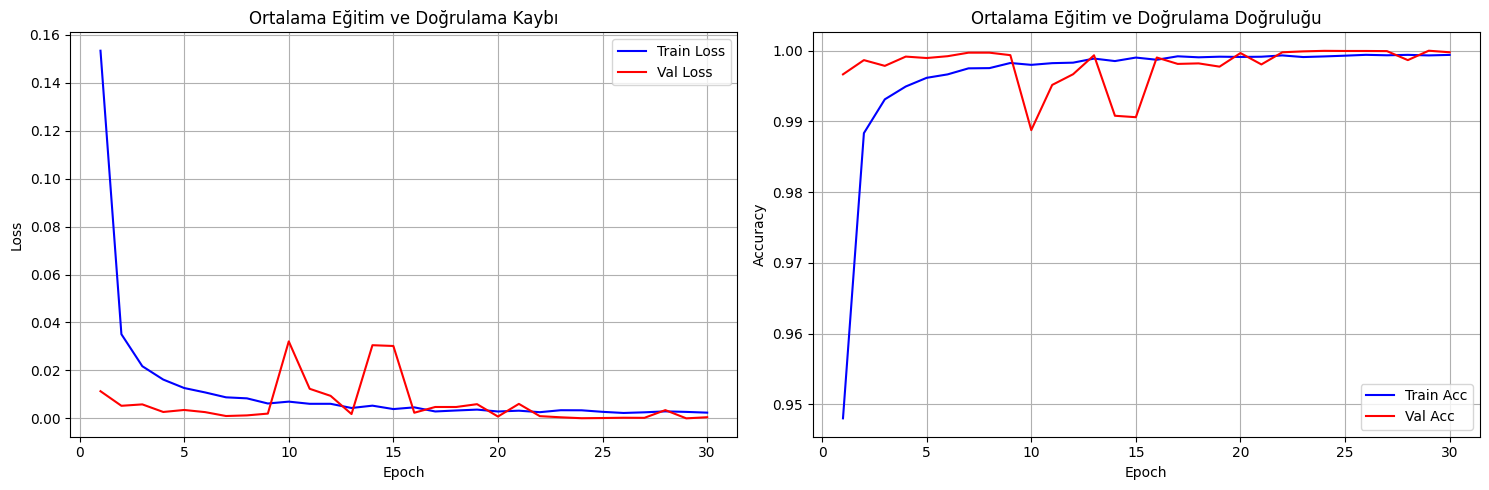

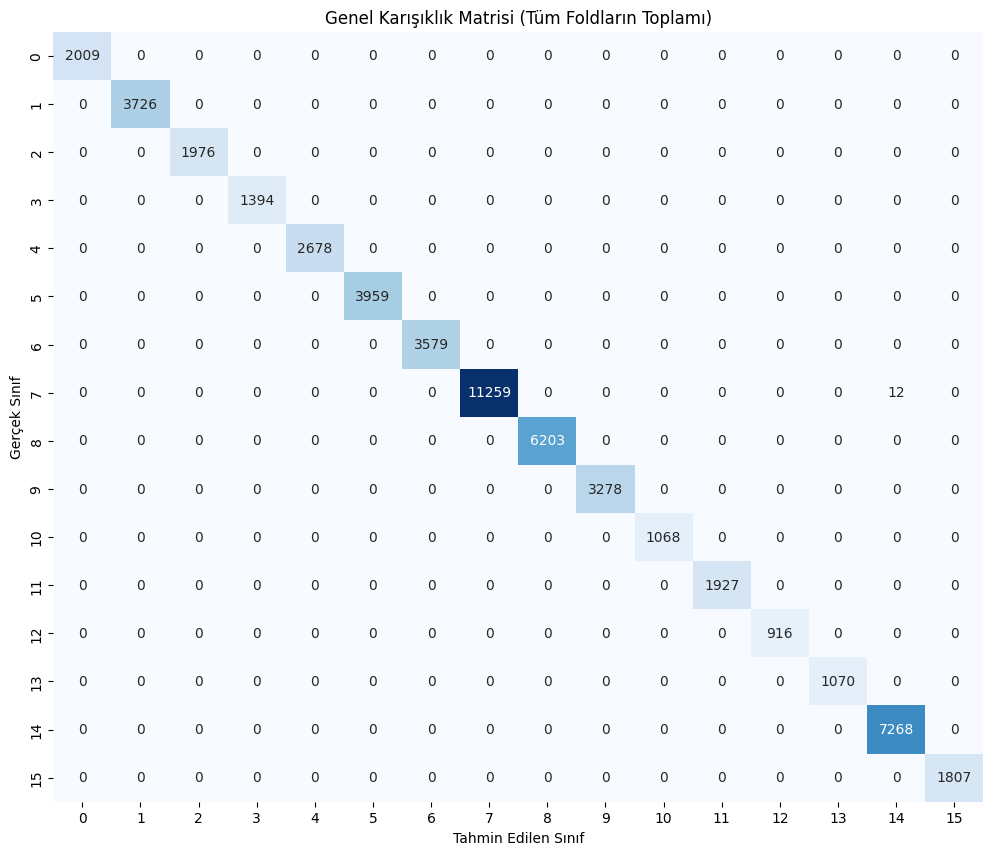

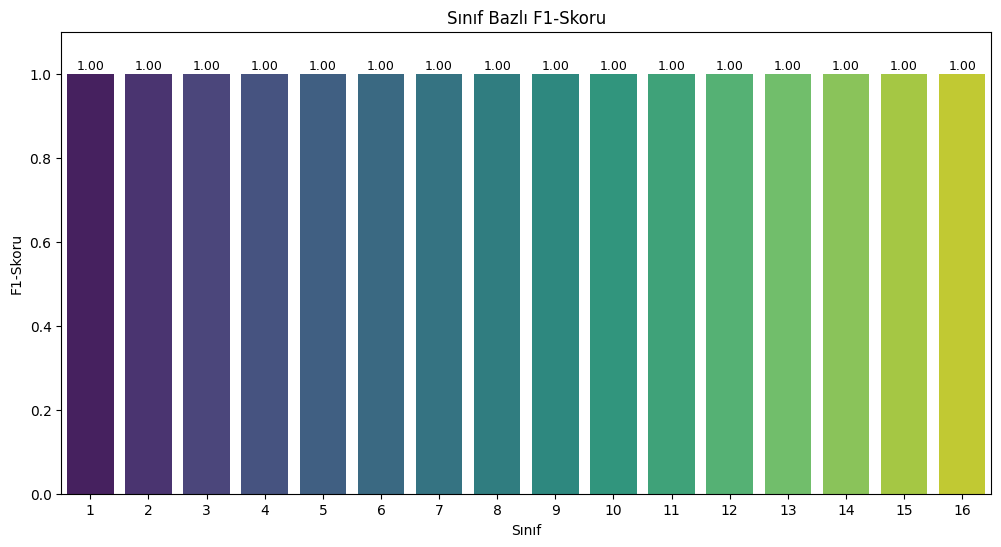

In [7]:
mean_train_loss = np.mean(history['train_loss'], axis=0)
mean_val_loss   = np.mean(history['val_loss'],   axis=0)
mean_train_acc  = np.mean(history['train_acc'],  axis=0)
mean_val_acc    = np.mean(history['val_acc'],    axis=0)
epochs = range(1, num_epochs + 1)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].plot(epochs, mean_train_loss, 'b-', label='Train Loss')
axes[0].plot(epochs, mean_val_loss,   'r-', label='Val Loss')
axes[0].set_title('Ortalama Eğitim ve Doğrulama Kaybı')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True)

axes[1].plot(epochs, mean_train_acc, 'b-', label='Train Acc')
axes[1].plot(epochs, mean_val_acc,   'r-', label='Val Acc')
axes[1].set_title('Ortalama Eğitim ve Doğrulama Doğruluğu')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(True)
plt.tight_layout(); plt.show()

plt.figure(figsize=(12, 10))
cm = confusion_matrix(oof_labels, oof_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Genel Karışıklık Matrisi (Tüm Foldların Toplamı)')
plt.xlabel('Tahmin Edilen Sınıf'); plt.ylabel('Gerçek Sınıf')
plt.show()

report  = classification_report(oof_labels, oof_preds, output_dict=True)
classes = [k for k in report.keys() if k.isdigit()]
f1_scores = [report[k]['f1-score'] for k in classes]

plt.figure(figsize=(12, 6))
sns.barplot(x=classes, y=f1_scores, hue=classes, palette='viridis', dodge=False, legend=False)
plt.title('Sınıf Bazlı F1-Skoru')
plt.xlabel('Sınıf'); plt.ylabel('F1-Skoru'); plt.ylim(0, 1.1)
for i, v in enumerate(f1_scores):
    plt.text(i, v + 0.01, f'{v:.2f}', ha='center', fontsize=9)
plt.show()

### Adım 8: Model Kaydı

In [8]:
import shutil

model_save_path = f'cnn3d_model_{dataset_prefix}.pth'
torch.save(model.state_dict(), model_save_path)
print(f"Model başarıyla '{model_save_path}' konumuna kaydedildi.")

if IN_COLAB:
    drive_save_path = os.path.join('/content/drive/MyDrive/models', model_save_path)
    os.makedirs(os.path.dirname(drive_save_path), exist_ok=True)
    shutil.copy(model_save_path, drive_save_path)
    print(f"Model Google Drive'a '{drive_save_path}' konumuna kopyalandı.")

Model başarıyla 'cnn3d_model_salinas_gauss0.5_pca30.pth' konumuna kaydedildi.
Model Google Drive'a '/content/drive/MyDrive/models/cnn3d_model_salinas_gauss0.5_pca30.pth' konumuna kopyalandı.
